Device: cuda
Train CSV: 496 rows | Persons: 62
Test  CSV: 204  rows
Building file indexes...
Train index: 496 passages | Test index: 204 folders

Identity-split:
  Train IDs: 47 | Train passages: 376
  Val   IDs: 15  | Val   passages: 120
  Classifier heads: 47

Train batches: 23 | Val batches: 8


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Parameters: 111.3M

TRAINING — ViT-Base + Cross-Modal + MixUp/CutMix
Evaluated with embedding CMC@1 (correct Re-ID metric)
Epoch   5/80 | Train Loss: 3.8689 | Val CMC@1: 38.3% | Best: 38.3% | LR: 1.20e-04
Epoch  10/80 | Train Loss: 3.1141 | Val CMC@1: 80.8% | Best: 80.8% | LR: 2.00e-04
Epoch  15/80 | Train Loss: 2.4293 | Val CMC@1: 86.7% | Best: 86.7% | LR: 1.97e-04
Epoch  20/80 | Train Loss: 2.0494 | Val CMC@1: 91.7% | Best: 91.7% | LR: 1.90e-04
Epoch  25/80 | Train Loss: 1.7660 | Val CMC@1: 93.3% | Best: 93.3% | LR: 1.78e-04
Epoch  30/80 | Train Loss: 1.9045 | Val CMC@1: 95.0% | Best: 95.0% | LR: 1.62e-04
Epoch  35/80 | Train Loss: 1.6190 | Val CMC@1: 92.5% | Best: 95.0% | LR: 1.43e-04
Epoch  40/80 | Train Loss: 1.7279 | Val CMC@1: 96.7% | Best: 96.7% | LR: 1.22e-04
Epoch  45/80 | Train Loss: 1.7848 | Val CMC@1: 95.8% | Best: 96.7% | LR: 1.00e-04
Epoch  50/80 | Train Loss: 1.7905 | Val CMC@1: 95.0% | Best: 96.7% | LR: 7.78e-05
Epoch  55/80 | Train Loss: 1.7136 | Val CMC@1: 95.0% | Be

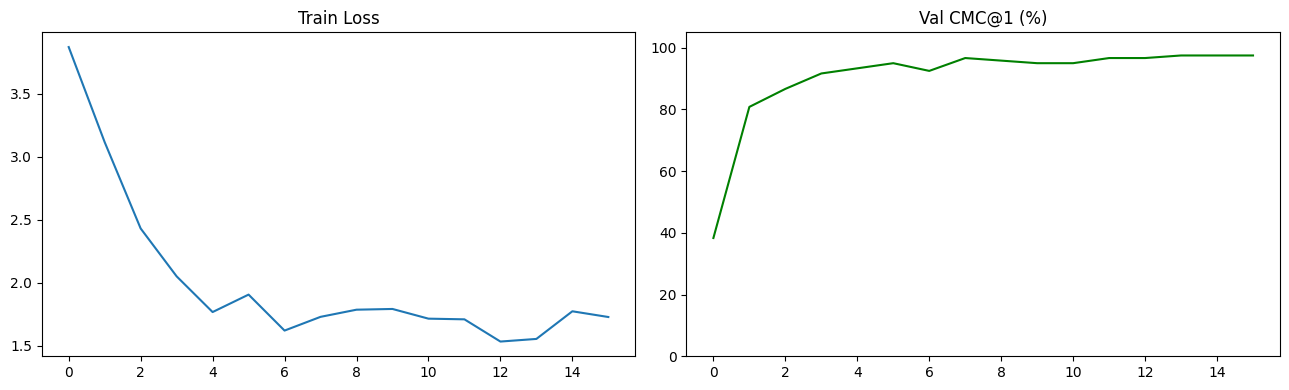


Best model loaded.

Building test gallery from CSV + file index...
Test gallery entries: 204

Extracting test embeddings (all frames + 5-way TTA)...
  Extracted 50/204 gallery entries
  Extracted 100/204 gallery entries
  Extracted 150/204 gallery entries
  Extracted 200/204 gallery entries
  Extracted 204/204 gallery entries
Gallery matrix: torch.Size([204, 768])

Generating ranked lists...
Ranking rows: 41616
  query_gallery_id                                                                                                          query_path gallery_id                                                                                                         gallery_path  rank  distance
0           bzrrcb  /kaggle/input/datasets/souravsheoran010/tvrid-full-test/tvrid_test_part4/bzrrcb/2024_10_23_14_17_09_845625_RGB.png     na66z1   /kaggle/input/datasets/souravsheoran010/tvrid-full-test/tvrid_test_part7/na66z1/2024_10_23_14_17_15_094332_RGB.png     1  0.097168
1           bzrrcb  /kaggl

In [3]:

!pip install timm pytorch-metric-learning -q

import os, random, math, gc
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from pytorch_metric_learning import losses, miners
from torch.amp import autocast, GradScaler

# ============================================================
# SEED & DEVICE
# ============================================================
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ============================================================
# CONFIG
# ============================================================
class CFG:
    # ── Paths (Kaggle layout) ────────────────────────────────
    train_base   = "/kaggle/input/datasets/souravsheoran010/tvrid-full-train"
    test_base    = "/kaggle/input/datasets/souravsheoran010/tvrid-full-test"
    train_csv    = "/kaggle/input/datasets/souravsheoran010/tvrid-datasets/train_labels.csv"
    test_csv     = "/kaggle/input/datasets/souravsheoran010/tvrid-datasets/public_test_labels.csv"

    # ── Model ───────────────────────────────────────────────
    backbone_rgb = "vit_base_patch16_224"
    backbone_dep = "vit_small_patch16_224"
    img_size     = 224
    embed_dim    = 768

    # ── Training ────────────────────────────────────────────
    epochs        = 80
    warmup_epochs = 10
    batch_size    = 16
    lr            = 2e-4
    min_lr        = 1e-7
    weight_decay  = 1e-4
    re_prob       = 0.35
    mixup_alpha   = 0.4
    cutmix_alpha  = 0.4
    label_smooth  = 0.1
    trip_weight   = 0.5
    trip_margin   = 0.3

    # ── Identity split (by person_id, NOT random rows) ──────
    val_ratio     = 0.25            # fraction of unique IDs for val

    device        = DEVICE

# ============================================================
# LOAD CSV
# ============================================================
train_df = pd.read_csv(CFG.train_csv)
test_df  = pd.read_csv(CFG.test_csv)
print(f"Train CSV: {len(train_df)} rows | Persons: {train_df['person_id'].nunique()}")
print(f"Test  CSV: {len(test_df)}  rows")

# ============================================================
# BUILD FILE INDEXES
# ============================================================
def normalize_path(p): return str(p).replace("\\", "/")

def build_train_index(base_path):
    """Returns {(person_id_str, cam_str, passage_str): [(rgb_path, dep_path), ...]}"""
    index = {}
    for part_dir in sorted(Path(base_path).iterdir()):
        if not part_dir.is_dir(): continue
        for person_dir in sorted(part_dir.iterdir()):
            if not person_dir.is_dir(): continue
            for cam_dir in sorted(person_dir.iterdir()):
                if not cam_dir.is_dir(): continue
                for passage_dir in sorted(cam_dir.iterdir()):
                    if not passage_dir.is_dir(): continue
                    rgb_files = sorted(passage_dir.glob("*RGB*.png"))
                    depth_map = {d.name.replace("_depth.png", ""): d
                                 for d in passage_dir.glob("*depth*.png")}
                    pairs = [(str(r), str(depth_map[r.name.replace("_RGB.png", "")]))
                             for r in rgb_files
                             if r.name.replace("_RGB.png", "") in depth_map]
                    if pairs:
                        key = (person_dir.name, cam_dir.name, passage_dir.name)
                        index[key] = pairs
    return index

def build_test_index(base_path):
    """Returns {gallery_id_str: [(rgb_path, dep_path), ...]}"""
    index = {}
    for part_dir in sorted(Path(base_path).iterdir()):
        if not part_dir.is_dir(): continue
        for folder_dir in sorted(part_dir.iterdir()):
            if not folder_dir.is_dir(): continue
            rgb_files = sorted(folder_dir.glob("*RGB*.png"))
            depth_map = {d.name.replace("_depth.png", ""): d
                         for d in folder_dir.glob("*depth*.png")}
            pairs = [(str(r), str(depth_map[r.name.replace("_RGB.png", "")]))
                     for r in rgb_files
                     if r.name.replace("_RGB.png", "") in depth_map]
            if pairs:
                index[folder_dir.name] = pairs
    return index

print("Building file indexes...")
train_index = build_train_index(CFG.train_base)
test_index  = build_test_index(CFG.test_base)
print(f"Train index: {len(train_index)} passages | Test index: {len(test_index)} folders")

# ============================================================
# BUILD SAMPLES  —  SPLIT BY IDENTITY (no leakage)
# ============================================================
samples = []
for _, row in train_df.iterrows():
    parts = normalize_path(row["path"]).split("/")
    key   = (parts[0], parts[1], parts[2])          # (person, cam, passage)
    if key in train_index:
        samples.append({
            "pid":       int(row["person_id"]),
            "cam":       int(row["cam_id"]),
            "gallery_id": normalize_path(row["path"]).rsplit("/", 1)[0],
            "all_pairs": train_index[key]
        })

all_pids = sorted(set(s["pid"] for s in samples))
random.shuffle(all_pids)
n_val       = max(1, int(len(all_pids) * CFG.val_ratio))
val_pids    = set(all_pids[:n_val])
train_pids  = set(all_pids[n_val:])

train_samples = [s for s in samples if s["pid"] in train_pids]
val_samples   = [s for s in samples if s["pid"] in val_pids]

pid2label  = {p: i for i, p in enumerate(sorted(train_pids))}
num_ids    = len(pid2label)

# Val gets its own label map (for internal metric calc only)
val_pid2label = {p: i for i, p in enumerate(sorted(val_pids))}

print(f"\nIdentity-split:")
print(f"  Train IDs: {len(train_pids)} | Train passages: {len(train_samples)}")
print(f"  Val   IDs: {len(val_pids)}  | Val   passages: {len(val_samples)}")
print(f"  Classifier heads: {num_ids}")

# ============================================================
# TRANSFORMS
# ============================================================
def get_transforms(split="train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if split == "train":
        return T.Compose([
            T.Resize((CFG.img_size + 32, CFG.img_size + 32)),
            T.RandomCrop(CFG.img_size),
            T.RandomHorizontalFlip(),
            T.RandomRotation(20),
            T.ColorJitter(0.4, 0.4, 0.3, 0.1),
            T.RandomGrayscale(p=0.1),
            T.ToTensor(),
            T.Normalize(mean, std),
            T.RandomErasing(p=CFG.re_prob, scale=(0.02, 0.33))
        ])
    return T.Compose([
        T.Resize((CFG.img_size, CFG.img_size)),
        T.ToTensor(),
        T.Normalize(mean, std)
    ])

def load_depth(path):
    img = Image.open(path)
    arr = np.array(img).astype(np.float32)
    if arr.max() > 0:
        arr = (arr / arr.max() * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    elif arr.shape[2] == 4:
        arr = arr[:, :, :3]
    return Image.fromarray(arr)

# ============================================================
# MIXUP & CUTMIX
# ============================================================
def mixup_data(x1, x2, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x1.size(0), device=x1.device)
    return (lam*x1 + (1-lam)*x1[idx],
            lam*x2 + (1-lam)*x2[idx],
            y, y[idx], lam)

def cutmix_data(x1, x2, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x1.size(0), device=x1.device)
    W, H   = x1.size(3), x1.size(2)
    cut_w  = int(W * math.sqrt(1 - lam))
    cut_h  = int(H * math.sqrt(1 - lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1b, x2b = max(0, cx-cut_w//2), min(W, cx+cut_w//2)
    y1b, y2b = max(0, cy-cut_h//2), min(H, cy+cut_h//2)
    x1n, x2n = x1.clone(), x2.clone()
    x1n[:, :, y1b:y2b, x1b:x2b] = x1[idx, :, y1b:y2b, x1b:x2b]
    x2n[:, :, y1b:y2b, x1b:x2b] = x2[idx, :, y1b:y2b, x1b:x2b]
    lam = 1 - (x2b-x1b)*(y2b-y1b)/(W*H)
    return x1n, x2n, y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1-lam) * criterion(pred, y_b)

# ============================================================
# DATASET
# ============================================================
class TVRIDDataset(Dataset):
    def __init__(self, samples, pid2label, split="train"):
        self.samples   = samples
        self.pid2label = pid2label
        self.split     = split
        self.tf        = get_transforms(split)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        if self.split == "train":
            pair = random.choice(s["all_pairs"])
        else:
            pair = s["all_pairs"][len(s["all_pairs"]) // 2]

        rgb = Image.open(pair[0]).convert("RGB")
        dep = load_depth(pair[1])

        seed = random.randint(0, 99999)
        torch.manual_seed(seed); random.seed(seed)
        rgb_t = self.tf(rgb)
        torch.manual_seed(seed); random.seed(seed)
        dep_t = self.tf(dep)

        label = self.pid2label.get(s["pid"], -1)
        return rgb_t, dep_t, label, s["pid"]

train_ds = TVRIDDataset(train_samples, pid2label, "train")
val_ds   = TVRIDDataset(val_samples,   val_pid2label, "val")

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size,
                          shuffle=True,  num_workers=4,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size,
                          shuffle=False, num_workers=4,
                          pin_memory=True)
print(f"\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ============================================================
# MODEL — ViT-Base Dual Stream + Cross-Modal Attention
# ============================================================
class TVRIDModel(nn.Module):
    def __init__(self, num_ids):
        super().__init__()
        self.rgb_enc = timm.create_model(CFG.backbone_rgb, pretrained=True, num_classes=0)
        self.dep_enc = timm.create_model(CFG.backbone_dep, pretrained=True, num_classes=0)

        rgb_dim = self.rgb_enc.num_features   # 768
        dep_dim = self.dep_enc.num_features   # 384

        self.dep_proj = nn.Sequential(
            nn.Linear(dep_dim, rgb_dim),
            nn.LayerNorm(rgb_dim)
        )
        self.cross_attn = nn.MultiheadAttention(rgb_dim, num_heads=8, batch_first=True)
        self.cross_norm = nn.LayerNorm(rgb_dim)

        self.fusion = nn.Sequential(
            nn.Linear(rgb_dim * 2, CFG.embed_dim),
            nn.BatchNorm1d(CFG.embed_dim),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        self.bnneck = nn.BatchNorm1d(CFG.embed_dim)
        self.bnneck.bias.requires_grad_(False)
        self.classifier = nn.Linear(CFG.embed_dim, num_ids, bias=False)
        nn.init.normal_(self.classifier.weight, std=0.01)

    def encode(self, rgb, dep):
        f_rgb  = self.rgb_enc(rgb)                          # [B, 768]
        f_dep  = self.dep_enc(dep)                          # [B, 384]
        f_dep  = self.dep_proj(f_dep)                       # [B, 768]
        f_cross, _ = self.cross_attn(
            f_rgb.unsqueeze(1), f_dep.unsqueeze(1), f_dep.unsqueeze(1))
        f_cross = self.cross_norm(f_cross.squeeze(1))
        feat   = self.fusion(torch.cat([f_rgb, f_cross], dim=1))
        return self.bnneck(feat)                            # L2-ready embedding

    def forward(self, rgb, dep):
        feat = self.encode(rgb, dep)
        return feat, self.classifier(feat)

model = TVRIDModel(num_ids=num_ids).to(CFG.device)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")

# ============================================================
# LOSS, OPTIMIZER, SCHEDULER
# ============================================================
ce_loss   = nn.CrossEntropyLoss(label_smoothing=CFG.label_smooth)
trip_loss = losses.TripletMarginLoss(margin=CFG.trip_margin)
miner     = miners.MultiSimilarityMiner(epsilon=0.1)
scaler    = GradScaler("cuda")

optimizer = torch.optim.AdamW([
    {"params": list(model.rgb_enc.parameters()) +
               list(model.dep_enc.parameters()),    "lr": CFG.lr * 0.05},
    {"params": list(model.dep_proj.parameters()) +
               list(model.cross_attn.parameters()) +
               list(model.cross_norm.parameters()) +
               list(model.fusion.parameters()) +
               list(model.bnneck.parameters()) +
               list(model.classifier.parameters()), "lr": CFG.lr}
], weight_decay=CFG.weight_decay)

def lr_lambda(epoch):
    if epoch < CFG.warmup_epochs:
        return (epoch + 1) / CFG.warmup_epochs
    prog = (epoch - CFG.warmup_epochs) / max(CFG.epochs - CFG.warmup_epochs, 1)
    return CFG.min_lr/CFG.lr + 0.5*(1 - CFG.min_lr/CFG.lr)*(1 + math.cos(math.pi*prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ============================================================
# LOCAL RE-ID METRIC — CMC@1 on val (embedding-based, not logit)
# ============================================================
@torch.no_grad()
def compute_val_cmc1(model, val_loader, device):
    """
    Compute CMC@1 on the validation set using embedding similarity.
    Each sample is a query; we rank all others as gallery.
    """
    model.eval()
    all_embs, all_pids = [], []

    for rgb, dep, label, pid in val_loader:
        rgb = rgb.to(device); dep = dep.to(device)
        with autocast("cuda"):
            emb = model.encode(rgb, dep)
        emb = F.normalize(emb, dim=1)
        all_embs.append(emb.cpu())
        all_pids.extend(pid.tolist())

    all_embs = torch.cat(all_embs, dim=0)   # [N, D]
    all_pids = torch.tensor(all_pids)

    sim  = all_embs @ all_embs.T             # [N, N] cosine sim
    sim.fill_diagonal_(-1e4)                 # exclude self

    top1_pid = all_pids[sim.argmax(dim=1)]
    cmc1     = (top1_pid == all_pids).float().mean().item()
    return cmc1

# ============================================================
# TRAINING LOOP
# ============================================================
best_cmc1 = 0.0
history   = {"train_loss": [], "val_cmc1": []}

print("\n" + "="*60)
print("TRAINING — ViT-Base + Cross-Modal + MixUp/CutMix")
print("Evaluated with embedding CMC@1 (correct Re-ID metric)")
print("="*60)

for epoch in range(CFG.epochs):
    model.train()
    t_loss = 0.0

    for rgb, dep, label, pid in train_loader:
        rgb   = rgb.to(CFG.device)
        dep   = dep.to(CFG.device)
        label = label.to(CFG.device)

        # Skip samples with unknown labels (shouldn't happen but guard)
        mask = label >= 0
        if mask.sum() == 0: continue
        rgb, dep, label = rgb[mask], dep[mask], label[mask]

        r = random.random()
        if r < 0.33:
            rgb, dep, la, lb, lam = mixup_data(rgb, dep, label, CFG.mixup_alpha)
            use_mix = "mixup"
        elif r < 0.66:
            rgb, dep, la, lb, lam = cutmix_data(rgb, dep, label, CFG.cutmix_alpha)
            use_mix = "cutmix"
        else:
            la, lb, lam, use_mix = label, label, 1.0, "none"

        optimizer.zero_grad()
        with autocast("cuda"):
            feat, logits = model(rgb, dep)
            l_ce = (mixup_criterion(ce_loss, logits, la, lb, lam)
                    if use_mix != "none" else ce_loss(logits, label))
            pairs  = miner(feat, label)
            l_trip = (trip_loss(feat, label, pairs)
                      if pairs[0].numel() > 0
                      else torch.tensor(0.0, device=CFG.device))
            loss   = l_ce + CFG.trip_weight * l_trip

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item()

    scheduler.step()
    avg_train = t_loss / max(len(train_loader), 1)

    # Evaluate every 5 epochs
    if (epoch + 1) % 5 == 0:
        cmc1 = compute_val_cmc1(model, val_loader, CFG.device)
        history["train_loss"].append(avg_train)
        history["val_cmc1"].append(cmc1)

        if cmc1 >= best_cmc1:
            best_cmc1 = cmc1
            torch.save(model.state_dict(), "/kaggle/working/best_tvrid_model.pth")

        lr_now = optimizer.param_groups[1]["lr"]
        print(f"Epoch {epoch+1:3d}/{CFG.epochs} | "
              f"Train Loss: {avg_train:.4f} | "
              f"Val CMC@1: {cmc1*100:.1f}% | "
              f"Best: {best_cmc1*100:.1f}% | "
              f"LR: {lr_now:.2e}")

print(f"\nBest Val CMC@1: {best_cmc1*100:.1f}%")

# ============================================================
# PLOT
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history["train_loss"]); ax1.set_title("Train Loss")
ax2.plot([v*100 for v in history["val_cmc1"]], color="green")
ax2.set_title("Val CMC@1 (%)"); ax2.set_ylim(0, 105)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

# ============================================================
# INFERENCE HELPERS
# ============================================================
# 5-way TTA transforms
tta_transforms = [
    T.Compose([T.Resize((224, 224)),
               T.ToTensor(),
               T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((224, 224)),
               T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(),
               T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((256, 256)),
               T.CenterCrop(224),
               T.ToTensor(),
               T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((248, 248)),
               T.CenterCrop(224),
               T.ToTensor(),
               T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    T.Compose([T.Resize((256, 256)),
               T.RandomHorizontalFlip(p=1.0),
               T.CenterCrop(224),
               T.ToTensor(),
               T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

@torch.no_grad()
def extract_embedding(model, rgb_path, dep_path, device, use_tta=True):
    """Extract a single L2-normalized embedding for a (RGB, depth) pair."""
    rgb_img = Image.open(rgb_path).convert("RGB")
    dep_img = load_depth(dep_path)
    tfs = tta_transforms if use_tta else [tta_transforms[0]]
    embs = []
    for tf in tfs:
        rgb = tf(rgb_img).unsqueeze(0).to(device)
        dep = tf(dep_img).unsqueeze(0).to(device)
        with autocast("cuda"):
            e = model.encode(rgb, dep)
        embs.append(F.normalize(e, dim=1).cpu())
    return torch.stack(embs).mean(0)   # [1, D]

@torch.no_grad()
def extract_gallery_embeddings(model, index, device, use_tta=True):
    """
    For each gallery entry, average embeddings over ALL frames (+ TTA).
    Returns: {gallery_id: embedding tensor [1, D]}
    """
    gallery_embs  = {}
    gallery_paths = {}   # store representative path for CSV
    total = len(index)
    for i, (gallery_id, pairs) in enumerate(index.items()):
        frame_embs = []
        for rgb_p, dep_p in pairs:
            e = extract_embedding(model, rgb_p, dep_p, device, use_tta)
            frame_embs.append(e)
        gallery_embs[gallery_id]  = torch.stack(frame_embs).mean(0)   # [1, D]
        gallery_paths[gallery_id] = pairs[len(pairs)//2][0]            # mid frame
        if (i+1) % 50 == 0 or (i+1) == total:
            print(f"  Extracted {i+1}/{total} gallery entries")
    return gallery_embs, gallery_paths

# ============================================================
# LOAD BEST MODEL
# ============================================================
model.load_state_dict(torch.load("/kaggle/working/best_tvrid_model.pth",
                                 map_location=CFG.device))
model.eval()
print("\nBest model loaded.")

# ============================================================
# BUILD TEST GALLERY INDEX FROM test_csv
# ============================================================
# public_test_labels.csv has: gallery_id, path  (no person_id — that's hidden)
# We group paths by gallery_id to support multi-frame passages.

print("\nBuilding test gallery from CSV + file index...")

# Map gallery_id → list of (rgb_path, dep_path) from our file index
test_gallery_index = {}
for _, row in test_df.iterrows():
    gid = str(row["gallery_id"])
    if gid in test_index:
        test_gallery_index[gid] = test_index[gid]

print(f"Test gallery entries: {len(test_gallery_index)}")

# ============================================================
# EXTRACT TEST EMBEDDINGS  (all frames + 5-way TTA)
# ============================================================
print("\nExtracting test embeddings (all frames + 5-way TTA)...")
gallery_embs, gallery_paths = extract_gallery_embeddings(
    model, test_gallery_index, CFG.device, use_tta=True)

gallery_ids   = list(gallery_embs.keys())
emb_matrix    = torch.cat([gallery_embs[g] for g in gallery_ids], dim=0)  # [N, D]
emb_matrix    = F.normalize(emb_matrix, dim=1)

print(f"Gallery matrix: {emb_matrix.shape}")

# ============================================================
# GENERATE RANKED LISTS
# ============================================================
# Competition format: query_gallery_id, query_path, gallery_id, gallery_path, rank, distance
# Every gallery_id is treated as a QUERY and ranked against the rest (leave-one-out).
# This is the standard closed-set Re-ID evaluation protocol.

print("\nGenerating ranked lists...")
rows = []
N    = len(gallery_ids)

sim_matrix = emb_matrix @ emb_matrix.T   # [N, N] cosine similarities

for qi, q_id in enumerate(gallery_ids):
    sims = sim_matrix[qi].clone()
    sims[qi] = -1e9                       # exclude self-match

    # Sort by descending similarity (ascending distance)
    order     = sims.argsort(descending=True)
    q_path    = gallery_paths[q_id]

    for rank, gi in enumerate(order.tolist(), start=1):
        g_id    = gallery_ids[gi]
        g_path  = gallery_paths[g_id]
        dist    = float(1.0 - sims[gi].item())   # cosine distance ∈ [0, 2]
        rows.append({
            "query_gallery_id": q_id,
            "query_path":       q_path,
            "gallery_id":       g_id,
            "gallery_path":     g_path,
            "rank":             rank,
            "distance":         round(dist, 6)
        })

ranking_df = pd.DataFrame(rows)
print(f"Ranking rows: {len(ranking_df)}")
print(ranking_df.head(10).to_string())

# ============================================================
# SAVE RANKING CSV  (RGB track — adapt for depth/cross)
# ============================================================
out_path = "/kaggle/working/rankings_rgb.csv"
ranking_df.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# ============================================================
# DEPTH-ONLY TRACK (same model, depth branch only)
# ============================================================
# For the depth-only track we use only the depth encoder.
# We create a thin wrapper that feeds a blank RGB and real depth.

print("\n--- Generating Depth-track rankings ---")

@torch.no_grad()
def extract_depth_only_embedding(model, dep_path, device, use_tta=True):
    """Use a zero RGB tensor so only depth information flows through."""
    dep_img   = load_depth(dep_path)
    tfs = tta_transforms if use_tta else [tta_transforms[0]]
    embs = []
    for tf in tfs:
        dep  = tf(dep_img).unsqueeze(0).to(device)
        rgb  = torch.zeros_like(dep)               # blank RGB
        with autocast("cuda"):
            e = model.encode(rgb, dep)
        embs.append(F.normalize(e, dim=1).cpu())
    return torch.stack(embs).mean(0)

depth_embs = {}
for i, (gid, pairs) in enumerate(test_gallery_index.items()):
    frame_embs = []
    for _, dep_p in pairs:
        e = extract_depth_only_embedding(model, dep_p, CFG.device, use_tta=True)
        frame_embs.append(e)
    depth_embs[gid] = torch.stack(frame_embs).mean(0)
    if (i+1) % 50 == 0: print(f"  Depth {i+1}/{len(test_gallery_index)}")

depth_matrix = torch.cat([depth_embs[g] for g in gallery_ids], dim=0)
depth_matrix = F.normalize(depth_matrix, dim=1)
depth_sim    = depth_matrix @ depth_matrix.T

depth_rows = []
for qi, q_id in enumerate(gallery_ids):
    sims      = depth_sim[qi].clone()
    sims[qi]  = -1e9
    order     = sims.argsort(descending=True)
    q_path    = gallery_paths[q_id]
    for rank, gi in enumerate(order.tolist(), start=1):
        g_id  = gallery_ids[gi]
        dist  = float(1.0 - sims[gi].item())
        depth_rows.append({
            "query_gallery_id": q_id,
            "query_path":       q_path,
            "gallery_id":       g_id,
            "gallery_path":     gallery_paths[g_id],
            "rank":             rank,
            "distance":         round(dist, 6)
        })

depth_df = pd.DataFrame(depth_rows)
depth_df.to_csv("/kaggle/working/rankings_depth.csv", index=False)
print(f"Saved: /kaggle/working/rankings_depth.csv")

# ============================================================
# CROSS-MODAL TRACK  (RGB → Depth retrieval)
# ============================================================
# Query: RGB embeddings   |   Gallery: Depth embeddings
# Sim = rgb_emb @ depth_emb^T

print("\n--- Generating Cross-modal track rankings ---")

@torch.no_grad()
def extract_rgb_only_embedding(model, rgb_path, device, use_tta=True):
    rgb_img = Image.open(rgb_path).convert("RGB")
    tfs = tta_transforms if use_tta else [tta_transforms[0]]
    embs = []
    for tf in tfs:
        rgb  = tf(rgb_img).unsqueeze(0).to(device)
        dep  = torch.zeros_like(rgb)
        with autocast("cuda"):
            e = model.encode(rgb, dep)
        embs.append(F.normalize(e, dim=1).cpu())
    return torch.stack(embs).mean(0)

rgb_embs = {}
for i, (gid, pairs) in enumerate(test_gallery_index.items()):
    frame_embs = []
    for rgb_p, _ in pairs:
        e = extract_rgb_only_embedding(model, rgb_p, CFG.device, use_tta=True)
        frame_embs.append(e)
    rgb_embs[gid] = torch.stack(frame_embs).mean(0)
    if (i+1) % 50 == 0: print(f"  RGB {i+1}/{len(test_gallery_index)}")

rgb_matrix   = torch.cat([rgb_embs[g]   for g in gallery_ids], dim=0)
depth_matrix = torch.cat([depth_embs[g] for g in gallery_ids], dim=0)
rgb_matrix   = F.normalize(rgb_matrix,   dim=1)
depth_matrix = F.normalize(depth_matrix, dim=1)
cross_sim    = rgb_matrix @ depth_matrix.T   # [N, N]

cross_rows = []
for qi, q_id in enumerate(gallery_ids):
    sims      = cross_sim[qi].clone()
    sims[qi]  = -1e9                         # exclude self (same identity)
    order     = sims.argsort(descending=True)
    q_path    = gallery_paths[q_id]
    for rank, gi in enumerate(order.tolist(), start=1):
        g_id  = gallery_ids[gi]
        dist  = float(1.0 - sims[gi].item())
        cross_rows.append({
            "query_gallery_id": q_id,
            "query_path":       q_path,
            "gallery_id":       g_id,
            "gallery_path":     gallery_paths[g_id],
            "rank":             rank,
            "distance":         round(dist, 6)
        })

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv("/kaggle/working/rankings_cross.csv", index=False)
print(f"Saved: /kaggle/working/rankings_cross.csv")

# ============================================================
# PACKAGE SUBMISSION ZIP
# ============================================================
import zipfile

zip_path = "/kaggle/working/submission.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("/kaggle/working/rankings_rgb.csv",   "rankings_rgb.csv")
    zf.write("/kaggle/working/rankings_depth.csv",  "rankings_depth.csv")
    zf.write("/kaggle/working/rankings_cross.csv",  "rankings_cross.csv")

print(f"\n{'='*60}")
print(f"  SUBMISSION READY: {zip_path}")
print(f"{'='*60}")
print(f"  rankings_rgb.csv   — {len(ranking_df):,} rows")
print(f"  rankings_depth.csv — {len(depth_df):,} rows")
print(f"  rankings_cross.csv — {len(cross_df):,} rows")
print(f"\n  Upload submission.zip to Codabench:")
print(f"  https://www.codabench.org/competitions/12315/")
print(f"\n  Val CMC@1 (embedding-based, proper identity split): {best_cmc1*100:.1f}%")